In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%matplotlib inline
import tensorflow as tf
from keras.preprocessing.image import load_img
from PIL import Image
from keras.models import Sequential,Model
from keras.layers import Dense,Conv2D,Dropout,Flatten,MaxPooling2D,Input,BatchNormalization,Rescaling,ReLU,GlobalAveragePooling2D

In [2]:
dataset = r'C:\Users\kara\Desktop\DL\1\UTKFace'

In [3]:
image_paths=[]
age_labels=[]
gender_labels=[]

for filename in tqdm(os.listdir(dataset)):
    image_path=os.path.join(dataset,filename)
    temp = filename.split('_')
    age = int(temp[0])
    gender = int(temp[1])
    image_paths.append(image_path)
    age_labels.append(age)
    gender_labels.append(gender)

  0%|          | 0/23708 [00:00<?, ?it/s]

In [4]:
df = pd.DataFrame()
df['image'],df['age'],df['gender']=image_paths,age_labels,gender_labels
gender_dic = {0: 'Male', 1: 'Female'}
df['gender_name'] = df['gender'].map(gender_dic)
df.head()

,image,age,gender,gender_name
0,C:\Users\kara\Desktop\DL\1\UTKFace\100_0_0_201...,100,0,Male
1,C:\Users\kara\Desktop\DL\1\UTKFace\100_0_0_201...,100,0,Male
2,C:\Users\kara\Desktop\DL\1\UTKFace\100_1_0_201...,100,1,Female
3,C:\Users\kara\Desktop\DL\1\UTKFace\100_1_0_201...,100,1,Female
4,C:\Users\kara\Desktop\DL\1\UTKFace\100_1_0_201...,100,1,Female


Exploretory Data Analysis

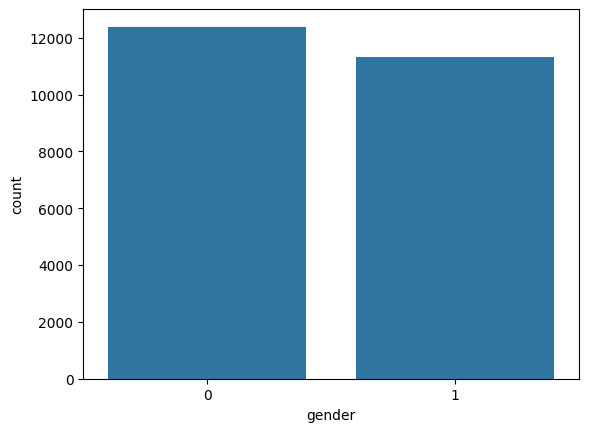

In [5]:


sns.countplot(x=df['gender'])
plt.show()

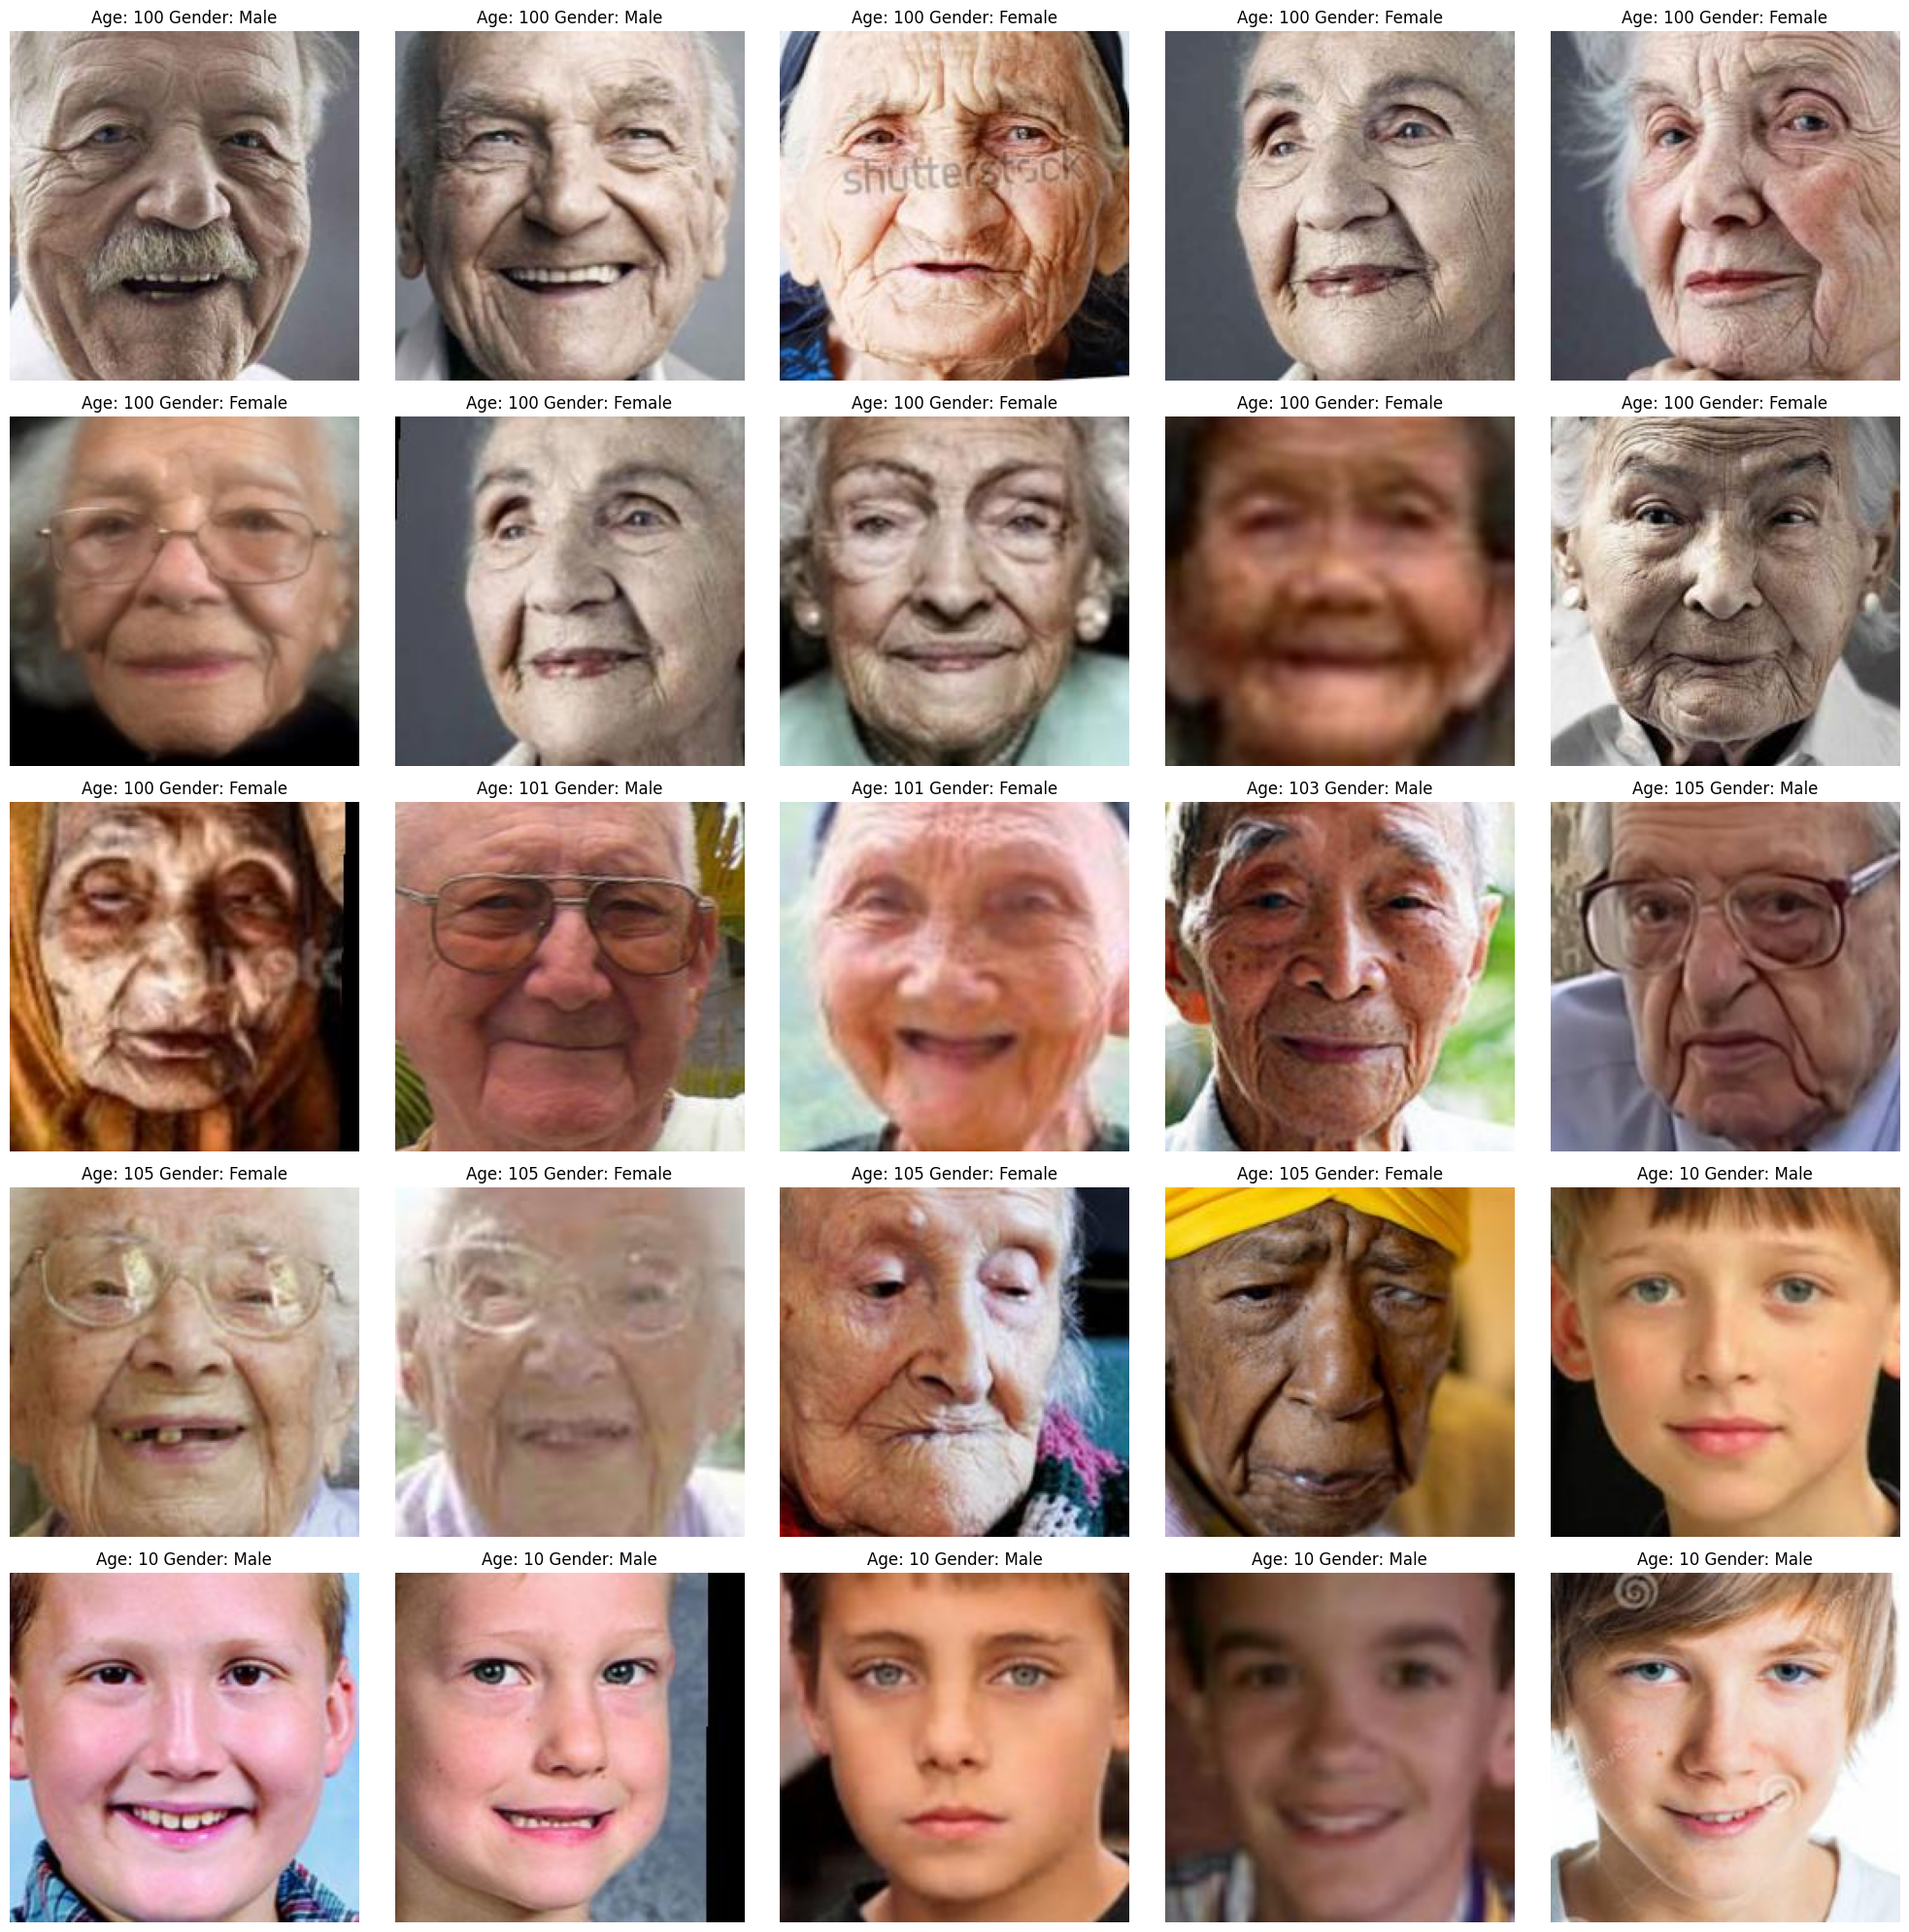

In [6]:
plt.figure(figsize=(20, 20))
files = df.iloc[0:25]
for index, file, age, gender, gender_name in files.itertuples():
    plt.subplot(5, 5, index + 1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title(f"Age: {age} Gender: {gender_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()


feature extraction

In [7]:
def feature_extraction(images):
    feature = []
    for image in tqdm(images):
        img = load_img(image)
        img = img.resize((128,128),Image.Resampling.LANCZOS)
        img = np.array(img)
        feature.append(img)
    feature =np.array(feature)
    return feature


In [8]:
X =feature_extraction(df['image'])

  0%|          | 0/23708 [00:00<?, ?it/s]

In [9]:
print(X.shape)

X = X/255.0
print(X.shape)
print(X.min(), X.max())
print(X.dtype)

(23708, 128, 128, 3)
(23708, 128, 128, 3)
0.0 1.0
float64


NORMALIZE

In [10]:
y_gender = np.array(df['gender'])
y_age = np.array(df['age'])
input_shape = (128,128,3)
from sklearn.model_selection import train_test_split

X_train, X_val, y_age_train, y_age_val, y_gender_train, y_gender_val = train_test_split(
    X,
    y_age,
    y_gender,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_val.shape)

print(y_age_train.shape)
print(y_age_val.shape)

print(y_gender_train.shape)
print(y_gender_val.shape)




(18966, 128, 128, 3)
(4742, 128, 128, 3)
(18966,)
(4742,)
(18966,)
(4742,)


Creating Model


In [11]:
inputs = Input((input_shape))
conv1=Conv2D(32,kernel_size=(3,3),activation=None)(inputs)
x =BatchNormalization()(conv1)
x = ReLU()(x)
maxp1 =MaxPooling2D(pool_size=(2,2))(x)

conv2=Conv2D(64,kernel_size=(3,3),activation=None)(maxp1)
x =BatchNormalization()(conv2)
x = ReLU()(x)
maxp2 =MaxPooling2D(pool_size=(2,2))(x)

conv3=Conv2D(128,kernel_size=(3,3),activation=None)(maxp2)
x =BatchNormalization()(conv3)
x = ReLU()(x)
maxp3 =MaxPooling2D(pool_size=(2,2))(x)


conv4=Conv2D(256,kernel_size=(3,3),activation=None)(maxp3)
x =BatchNormalization()(conv4)
x = ReLU()(x)
maxp4 =MaxPooling2D(pool_size=(2,2))(x)


flatten = Flatten()(maxp4)

dense_1=Dense(256,activation='relu')(flatten)
dense_2=Dense(256,activation='relu')(flatten)

dropout_1 = Dropout(0.4)(dense_1)
dropout_2 = Dropout(0.4)(dense_2)

output_1 = Dense(1,activation='sigmoid',name="gender_out")(dropout_1)
output_2 = Dense(1,activation='linear',name="age_out")(dropout_2)

model = Model(inputs=[inputs],outputs=[output_1,output_2])


In [13]:
model.compile(
    optimizer="adam",
    loss={
        "gender_out": "binary_crossentropy",
        "age_out": "mse"
    },
    metrics={
        "gender_out": ["accuracy"],
        "age_out": ["mae"]
    }
)

In [14]:
history = model.fit(
    X_train,
    {
        "gender_out": y_gender_train,
        "age_out": y_age_train
    },
    validation_data=(
        X_val,
        {
            "gender_out": y_gender_val,
            "age_out": y_age_val
        }
    ),
    epochs=10,
    batch_size=32
)

Epoch 1/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 276s 458ms/step - age_out_loss: 223.7671 - age_out_mae: 11.2182 - gender_out_accuracy: 0.7522 - gender_out_loss: 0.5802 - loss: 224.3924 - val_age_out_loss: 159.1249 - val_age_out_mae: 9.8485 - val_gender_out_accuracy: 0.8140 - val_gender_out_loss: 0.4171 - val_loss: 159.3304
Epoch 2/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 262s 442ms/step - age_out_loss: 138.9710 - age_out_mae: 8.8297 - gender_out_accuracy: 0.8108 - gender_out_loss: 0.4050 - loss: 139.3884 - val_age_out_loss: 151.9094 - val_age_out_mae: 9.9849 - val_gender_out_accuracy: 0.8408 - val_gender_out_loss: 0.3523 - val_loss: 152.4571
Epoch 3/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 266s 448ms/step - age_out_loss: 118.8658 - age_out_mae: 8.1455 - gender_out_accuracy: 0.8167 - gender_out_loss: 0.3721 - loss: 119.2615 - val_age_out_loss: 127.7115 - val_age_out_mae: 8.1773 - val_gender_out_accuracy: 0.8151 - val_gender_out_loss: 0.3680 - val_loss: 128.4769
Epoch 4/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 268s 452ms/

In [15]:
model.save("age_gender_mobilenetv2.keras")

Plot the Result

<Figure size 640x480 with 0 Axes>

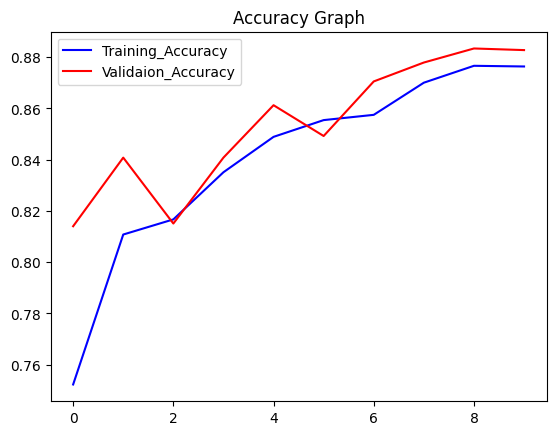

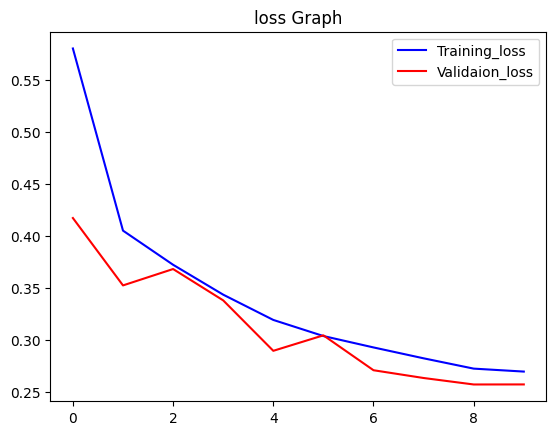

<Figure size 640x480 with 0 Axes>

In [18]:
acc = history.history['gender_out_accuracy']
val_acc = history.history['val_gender_out_accuracy']
epochs=range(len(acc))
plt.plot(epochs,acc,'b',label='Training_Accuracy')
plt.plot(epochs,val_acc,'r',label='Validaion_Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()
loss = history.history['gender_out_loss']
val_loss = history.history['val_gender_out_loss']
epochs=range(len(loss))
plt.plot(epochs,loss,'b',label='Training_loss')
plt.plot(epochs,val_loss ,'r',label='Validaion_loss')
plt.title('loss Graph')
plt.legend()
plt.figure()


Original gender: Male Original age: 17
Predicted Gender: Male Predicted Age: 19

Raw outputs:
Gender probability: 0.17795706
Age prediction: 18.511065


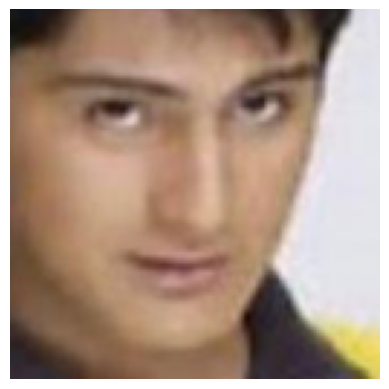

In [18]:
import tensorflow as tf
import matplotlib.pyplot as plt


# Load trained model
model = tf.keras.models.load_model(
    "age_gender_mobilenetv2.keras"
)


image_index =1111


print(
    "Original gender:",
    gender_dic[y_gender[image_index]],
    "Original age:",
    y_age[image_index]
)


pred = model.predict(
    X[image_index].reshape(1,128,128,3),
    verbose=0
)


# output_0 = gender
# output_1 = age

pred_gender = gender_dic[
    round(pred[0][0][0])
]

pred_age = round(
    pred[1][0][0]
)


print(
    "Predicted Gender:",
    pred_gender,
    "Predicted Age:",
    pred_age
)


print("\nRaw outputs:")
print("Gender probability:", pred[0][0][0])
print("Age prediction:", pred[1][0][0])


plt.axis("off")
plt.imshow(
    X[image_index].reshape(128,128,3)
)
plt.show()